# Practical 07 — Feature Reduction using PCA

## 1. Aim & Objectives

**Aim:** To perform feature reduction using Principal Component Analysis and visualise the transformed features.

**Objectives:**
1. Standardise the 30 features of the Breast Cancer dataset.
2. Apply PCA and study the explained variance of each principal component.
3. Project the data onto 2 components and plot it, then check the accuracy before and after PCA.

## 2. Complete Python Code


Shape of dataset : (569, 31)
Classes          : <StringArray>
['malignant', 'benign']
Length: 2, dtype: str

Variance explained by first 5 components : [0.4427 0.1897 0.0939 0.066  0.055 ]
Total variance kept by 2 components      : 0.6324
Components needed for 95% variance       : 10
Shape before PCA : (569, 30)  -> after PCA : (569, 2)
All 30 features accuracy : 0.9708
2 PCA components accuracy : 0.9415


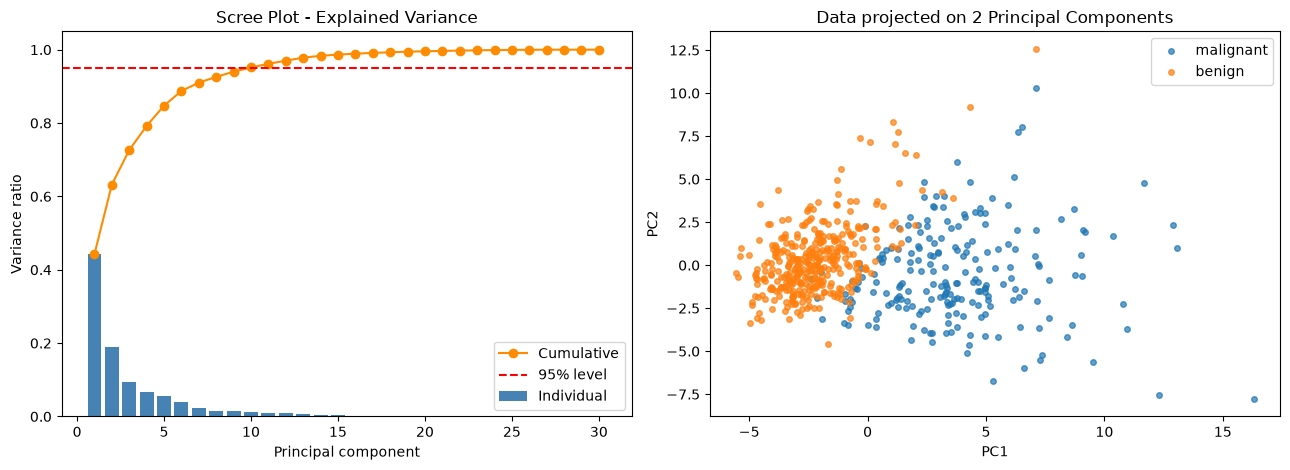

In [1]:
# Practical 07 - Feature Reduction using PCA
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Load the dataset
CSV = "data/breast_cancer.csv"
URL = "https://raw.githubusercontent.com/liamdev07/machine-learning-laboratory/main/07_PCA_Feature_Reduction/data/breast_cancer.csv"
path = CSV if os.path.exists(CSV) else URL
df = pd.read_csv(path)

print("Shape of dataset :", df.shape)
print("Classes          :", df["diagnosis"].unique())

X = df.drop(columns="diagnosis")
y = df["diagnosis"]

# Step 2: Standardise the features (PCA needs equal scales)
X_scaled = StandardScaler().fit_transform(X)

# Step 3: Apply PCA on all components to study the variance
pca_all = PCA()
pca_all.fit(X_scaled)
ratio = pca_all.explained_variance_ratio_
cumulative = np.cumsum(ratio)

print("\nVariance explained by first 5 components :", np.round(ratio[:5], 4))
print("Total variance kept by 2 components      :", round(cumulative[1], 4))
print("Components needed for 95% variance       :", int(np.argmax(cumulative >= 0.95) + 1))

# Step 4: Reduce the data to 2 components
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)
print("Shape before PCA :", X_scaled.shape, " -> after PCA :", X_pca.shape)

# Step 5: Compare accuracy before and after PCA
for name, data in [("All 30 features", X_scaled), ("2 PCA components", X_pca)]:
    X_tr, X_te, y_tr, y_te = train_test_split(data, y, test_size=0.3, random_state=42, stratify=y)
    clf = LogisticRegression(max_iter=5000).fit(X_tr, y_tr)
    print(name, "accuracy :", round(accuracy_score(y_te, clf.predict(X_te)), 4))

# Step 6: Plot the scree curve and the 2-D projection
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].bar(range(1, len(ratio) + 1), ratio, color="steelblue", label="Individual")
ax[0].plot(range(1, len(ratio) + 1), cumulative, color="darkorange", marker="o", label="Cumulative")
ax[0].axhline(0.95, color="red", linestyle="--", label="95% level")
ax[0].set_title("Scree Plot - Explained Variance")
ax[0].set_xlabel("Principal component")
ax[0].set_ylabel("Variance ratio")
ax[0].legend()

for label in df["diagnosis"].unique():
    mask = (y == label).to_numpy()
    ax[1].scatter(X_pca[mask, 0], X_pca[mask, 1], s=16, alpha=0.7, label=label)
ax[1].set_title("Data projected on 2 Principal Components")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
ax[1].legend()

plt.tight_layout()
plt.show()


## 3. Line-by-Line Code Explanation

- `from sklearn.decomposition import PCA` — Principal Component Analysis, which creates new features (components) that are combinations of the old ones.
- `X = df.drop(columns="diagnosis")` — the 30 numeric measurements of each tumour.
- `y = df["diagnosis"]` — the label, malignant or benign. PCA does **not** use this label; it is used only for colouring the plot.
- `StandardScaler().fit_transform(X)` — makes every column have mean 0 and standard deviation 1. Without this step, a large-valued column such as `mean area` would dominate the result.
- `PCA()` with no argument — keeps all components, so we can study how important each one is.
- `pca_all.explained_variance_ratio_` — the fraction of the total information (variance) captured by each component; the first component always captures the most.
- `np.cumsum(ratio)` — running total of that fraction, which tells us how much information the first q components keep together.
- `np.argmax(cumulative >= 0.95) + 1` — the smallest number of components needed to keep 95% of the information.
- `PCA(n_components=2)` — keeps only the two strongest components.
- `pca2.fit_transform(X_scaled)` — computes the components and projects the data, turning 30 columns into 2 columns.
- The `for name, data in [...]` loop — trains a Logistic Regression twice, first on all 30 scaled features and then on the 2 PCA features, to compare accuracy fairly.
- `LogisticRegression(max_iter=5000)` — a simple classifier; the higher `max_iter` just gives it enough steps to converge.
- `ax[0].bar(...)` and `ax[0].plot(...)` — the scree plot: bars for each component and an orange line for the cumulative total, with a red dashed line at the 95% level.
- The `for label in ...` loop with `ax[1].scatter(...)` — draws the 2-D projection, one colour per diagnosis.
- `plt.show()` — displays both graphs.


## 4. Output & Graph Interpretation

The scree plot shows that the first two components already capture a large share of the variance, and about 10 components are enough to reach the 95% level out of the original 30.

In the 2-D projection the malignant and benign groups form two clearly separated clouds, and the accuracy stays high even after reducing 30 features to only 2.
